In [1]:
!pip install torch torchvision torchaudio gymnasium gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from collections import deque

import matplotlib.pyplot as plt
from IPython.display import Video
import os

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


In [4]:
# CONFIGURATION
EPISODES        = 1000
GAMMA           = 0.99
LR              = 1e-4
BATCH_SIZE      = 64
BUFFER_SIZE     = 20_000
EPSILON_START   = 1.0
EPSILON_END     = 0.01
EPSILON_DECAY   = 0.995
TARGET_UPDATE   = 10
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
# Neural Network for DQN

class QNetwork(nn.Module):
  def __init__(self, state_dim: int, action_dim: int):
    super(QNetwork, self).__init__()

    # NN Layer: can be change in future
    self.net = nn.Sequential(
        nn.Linear(state_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 128),
        nn.ReLU(),
        nn.Linear(128, action_dim)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.net(x)

In [6]:
# Replay Buffer

class ReplayBuffer:
  def __init__(self, buffer_size: int):
    self.buffer = deque(maxlen=buffer_size)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self, batch_size: int):
    batch = random.sample(self.buffer, batch_size)
    states, action, reward, next_state, done = zip(*batch)

    return (
        torch.FloatTensor(np.array(states)).to(DEVICE),
        torch.LongTensor(action).to(DEVICE),
        torch.FloatTensor(reward).to(DEVICE),
        torch.FloatTensor(np.array(next_state)).to(DEVICE),
        torch.FloatTensor(done).to(DEVICE)
    )

  def __len__(self):
    return len(self.buffer)

In [7]:
# DQN Agent
class DQNAgent:
  def __init__(self, state_dim: int, action_dim: int):
    self.action_dim = action_dim

    self.online_net = QNetwork(state_dim, action_dim).to(DEVICE)
    self.target_net = QNetwork(state_dim, action_dim).to(DEVICE)
    self.target_net.load_state_dict(self.online_net.state_dict())
    self.target_net.eval()

    self.optimizer = optim.Adam(self.online_net.parameters(), lr=LR)
    self.loss_fn = nn.MSELoss()

    self.buffer = ReplayBuffer(BUFFER_SIZE)

    self.epsilon = EPSILON_START

  def select_action(self, state: np.array) -> int:
    if random.random() < self.epsilon:
      return random.randint(0, self.action_dim - 1)

    with torch.no_grad():
      state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
      q_values = self.online_net(state_t)
      return q_values.argmax(dim=1).item()

  def learn(self):
    if len(self.buffer) < BATCH_SIZE:
      return

    states, actions, rewards, next_states, dones = self.buffer.sample(BATCH_SIZE)

    q_pred = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
      q_next = self.target_net(next_states).max(dim=1).values
      q_target = rewards + GAMMA * q_next * (1.0 - dones)

    loss = self.loss_fn(q_pred, q_target)
    self.optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
    self.optimizer.step()

  def update_target_net(self):
    self.target_net.load_state_dict(self.online_net.state_dict())

  def decay_epsilon(self):
    self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)

In [8]:
#F(s, a, s') = γ · Φ(s') − Φ(s)
def reshape_reward(state: np.array, next_state: np.array, raw_reward: float) -> float:
  phi_s = state[0] + 10 * abs(state[1])
  phi_next_s = next_state[0] + 10 * abs(next_state[1])
  return raw_reward + GAMMA * phi_next_s - phi_s

In [9]:
# train function

def train():
  env = gym.make("MountainCar-v0")

  state_dim = env.observation_space.shape[0]
  action_dim = env.action_space.n

  agent = DQNAgent(state_dim, action_dim)
  reward_history = []

  print(f"Training DQN on MountainCar-v0 | Device: {DEVICE}")
  print(f"State dim: {state_dim}, Action dim: {action_dim}")
  print("-" * 60)

  for episode in range (1, EPISODES + 1):
    state, _ = env.reset()

    total_reward = 0
    done = False

    while not done:
      state = np.array(state)
      action = agent.select_action(state)
      next_state, reward, terminated, truncated, _ = env.step(action)
      done = terminated

      if terminated:
        print(f"Terminated Episode: {episode}")

      reward_store = reshape_reward(state, next_state, reward)
      if terminated:
        reward_store = 100 # Success signal
      agent.buffer.push(state, action, reward_store, np.array(next_state), float(done))
      state = next_state
      total_reward += reward

      agent.learn()

    agent.decay_epsilon()
    reward_history.append(total_reward)

    # LOGGING
    if episode % 10 == 0:
      avg_reward = np.mean(reward_history[-10:])
      print(
          f"Episode {episode:4d} | "
          f"Avg Reward (last 10): {avg_reward:6.1f} | "
          f"Epsilon: {agent.epsilon:.3f}"
      )

    if episode % TARGET_UPDATE == 0:
      agent.update_target_net()

  env.close()
  return agent, reward_history

In [10]:
agent, history = train()

print("\nTraining selesai!")
print(f"Total episode: {len(history)}")
print(f"Reward akhir (rata-rata 10 episode terakhir): {np.mean(history[-10:]):.1f}")

Training DQN on MountainCar-v0 | Device: cpu
State dim: 2, Action dim: 3
------------------------------------------------------------
Terminated Episode: 1
Terminated Episode: 2
Terminated Episode: 3
Terminated Episode: 4
Terminated Episode: 5
Terminated Episode: 6
Terminated Episode: 7
Terminated Episode: 8
Terminated Episode: 9
Terminated Episode: 10
Episode   10 | Avg Reward (last 10): -14288.7 | Epsilon: 0.951
Terminated Episode: 11
Terminated Episode: 12
Terminated Episode: 13
Terminated Episode: 14
Terminated Episode: 15
Terminated Episode: 16
Terminated Episode: 17
Terminated Episode: 18
Terminated Episode: 19
Terminated Episode: 20
Episode   20 | Avg Reward (last 10): -4524.4 | Epsilon: 0.905
Terminated Episode: 21
Terminated Episode: 22
Terminated Episode: 23
Terminated Episode: 24
Terminated Episode: 25
Terminated Episode: 26
Terminated Episode: 27
Terminated Episode: 28
Terminated Episode: 29
Terminated Episode: 30
Episode   30 | Avg Reward (last 10): -2424.9 | Epsilon: 0.86

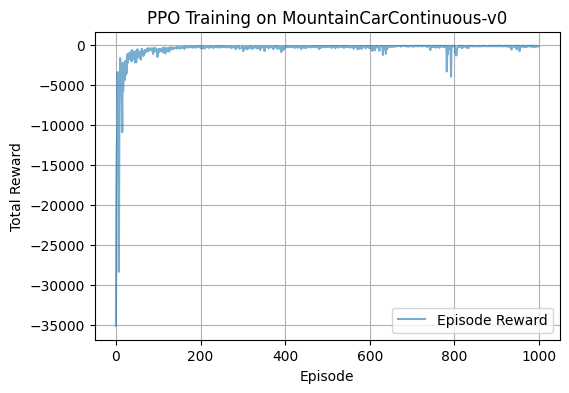

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history, alpha=0.6, label="Episode Reward")
plt.title("PPO Training on MountainCarContinuous-v0")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
def evaluate(agent: DQNAgent, n_episodes: int = 10):
    env = gym.make("MountainCar-v0")
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0

    rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = agent.select_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)

    agent.epsilon = old_epsilon
    env.close()

    print(f"\nEvaluasi ({n_episodes} episode):")
    print(f"  Rata-rata reward : {np.mean(rewards):.1f}")
    print(f"  Reward tertinggi : {np.max(rewards):.1f}")
    print(f"  Reward terendah  : {np.min(rewards):.1f}")
    return rewards

evaluate(agent, n_episodes=20)


Evaluasi (20 episode):
  Rata-rata reward : -130.3
  Reward tertinggi : -85.0
  Reward terendah  : -185.0


[-85.0,
 -150.0,
 -185.0,
 -111.0,
 -86.0,
 -172.0,
 -164.0,
 -164.0,
 -164.0,
 -87.0,
 -142.0,
 -91.0,
 -172.0,
 -86.0,
 -161.0,
 -91.0,
 -144.0,
 -97.0,
 -105.0,
 -149.0]